# Intraday Regime Detection: XGBoost vs. GaussianHMM

**Question:** Can a *supervised* model (XGBoost) match or beat the *unsupervised* GaussianHMM at detecting intraday market regimes from order-flow microstructure?

ALL data here is **synthetic** order-flow with known ground-truth regimes, so we can score both models agaisnt the truth. The generator mimics IDX-style intraday microstructure (session U-shapes, fat tails, aggressor flow). 

## TL;DR

| model | supervised? | ARI vs truth | accuracy | macro-F1 |
|---|---|---|---|---|
| GaussianHMM | no - clusters latent states | ~0.70 | - | -|
| XGBoost | yes  - trained on true regime | ~0.75 | ~0.90 | ~0.91 |

**The gap is small.** XGBoost, *given the answer key*, only edges out the unsupervised HMM. Two takeaways:
1. The HMM is **strong** - it recovers ~93% of the achievable seperation with zero labels.
2. The remaining errors are a **feature ceiling**, not a model failure: the regimes genuinely overlap, so even a
supervised model can't fully seperate them. XGBoost's real value is a **diagnostic** (which features carry signal) and a **performance ceiling**.

## Setup - a fair, like-for-like comparison

- **Same data:** one synthetic instrument, 40 days of 10 minute bars.
- **Same 6 features:** `ret, signed_vol_imb, ofi, rel_spread, realized_vol, trade_intensity`.
- **Same de-seasonalization & split:** features de-seasonalized with **train-only** stats; a single **time-ordered 70/30 split** (never shuffled - that leaks the future).
- **Sscoring:** both scored by **Adjusted Rand Index (ARI)** vs ground truth - permutation-invariant, so it works for the HMM's arbitrary state numbers. XGBoost also gets accuracy / macro-F1.
- **The key asymmetry:** the HMM is **unsupervised** (never sees lables); XGBoost is **unsupervised** (trains on the true regime - possible only because this is synthetic).

In [1]:
import sys
from pathlib import Path

# Make the src package importable from notebooks/
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (adjusted_rand_score, accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from src import config
from src.ingest.synthetic_adapter import SyntheticAdapter, REGIMES
from src.bars import build_bars
from src.features import compute_features
from src.seasonality import fit_seasonality, apply_seasonality
from src.backtest import train_and_backtest

REGIME_NAMES = {k: v["name"] for k, v in REGIMES.items()}
REGIME_NAMES    # 0 calm, 1 buy_pressure, 2 sell_pressure, 3 volatile

{0: 'calm', 1: 'buy_pressure', 2: 'sell_pressure', 3: 'volatile'}

In [2]:
# Synthetic order-flow with KNOWN ground-truth regimes (only possible on synthetic data).
adapter = SyntheticAdapter(symbol="DEMO", n_days=40, seed=7)
bars = build_bars(adapter.stream())     # consuming the stream fills adapter.truth
truth = adapter.truth                   # bar_start.isoformat() -> true regime id
features = compute_features(bars)       # 6 point-in-time features per bar

print(f"{len(features)} bars, features = {config.FEATURE_COLS}")
features.head()

1152 bars, features = ['ret', 'signed_vol_imb', 'ofi', 'rel_spread', 'realized_vol', 'trade_intensity']


,ret,signed_vol_imb,ofi,rel_spread,realized_vol,trade_intensity,close,slot,session_id,date
bar_start,,,,,,,,,,
2026-01-05 09:10:00+07:00,-0.002290,-0.014540,-18865.0,0.001196,0.000787,17.0,5015.0,09:10,0,2026-01-05
2026-01-05 09:20:00+07:00,-0.002396,0.099683,-9260.0,0.001199,0.000668,20.0,5003.0,09:20,0,2026-01-05
2026-01-05 09:30:00+07:00,-0.001901,-0.226819,-7424.0,0.001001,0.000397,10.0,4993.5,09:30,0,2026-01-05
2026-01-05 09:40:00+07:00,-0.016252,0.100176,-15158.0,0.002442,0.002026,31.0,4913.0,09:40,0,2026-01-05
2026-01-05 09:50:00+07:00,0.015251,0.690012,22060.0,0.002205,0.001680,29.0,4988.5,09:50,0,2026-01-05


In [3]:
# True regime per bar (the supervised label - available only because this is synthetic)
true_regime = pd.Series(features.index.map(lambda ts: truth.get(ts.isoformat())),
                        index = features.index, name="regime")
keep = true_regime.notna()
features, true_regime = features[keep], true_regime[keep].astype(int)

split = int(len(features) * config.TRAIN_RATIO)          # time-ordered 70/30

# De-seasonalize with TRAIN-only so BOTH models see the same fair representation
season = fit_seasonality(features.iloc[:split])
features_deseason = apply_seasonality(features, season)
regime_test = true_regime.iloc[split:]

print(f"train {split} bars | test {len(features) - split} bars")
print(true_regime.value_counts().rename(REGIME_NAMES).sort_index())

train 806 bars | test 346 bars
regime
buy_pressure     284
calm             496
sell_pressure    251
volatile         121
Name: count, dtype: int64


## Model A - GaussianHMM (unsupervised)

The HMM discovers hidden states from the feature stream, picks the number of states by BIC, and runs an honest online forward-filter (no-peeking at the future). It never sees the labels - we only use them to *score* it.

In [4]:
df_hmm, hmm_artifact, hmm_split = train_and_backtest(features)     # prints a BIC sweep
hmm_state_test = df_hmm["filt_state"].iloc[hmm_split:]
hmm_truth_test = df_hmm.index[hmm_split:].map(lambda ts: truth.get(ts.isoformat()))
mask = pd.notna(hmm_truth_test)
hmm_ari = adjusted_rand_score(np.array(hmm_truth_test)[mask].astype(int),
                              hmm_state_test.values[mask])
print(f"\nHMM states chosen (BIC): {hmm_artifact['meta']['n_states']}")
print(f"HMM test ARI vs truth:   {hmm_ari:.3f}")

n=2 | AIC: 10050.91 | BIC: 10318.36 | Converged: True
n=3 | AIC: 9081.31 | BIC: 9498.91 | Converged: True
n=4 | AIC: 8886.04 | BIC: 9463.16 | Converged: True
n=5 | AIC: 8810.17 | BIC: 9556.22 | Converged: True
n=6 | AIC: 8843.27 | BIC: 9767.61 | Converged: True

Best number of states by BIC: 4
HMM converged: True

HMM states chosen (BIC): 4
HMM test ARI vs truth:   0.702


## Model B - XGBoost (supervised)

XGBoost trains on the **true current regime** and learns to classify it from the same features. Classess are balanced so rare regimes are not ignored. This is the "best case with labels" - an upper bound on what these features can do.

In [5]:
# Trees don't need scaling, but we use the SAME de-seasonalized features as the HMM.
features_train = features_deseason[config.FEATURE_COLS].iloc[:split]
features_test = features_deseason[config.FEATURE_COLS].iloc[split:]
regime_train = true_regime.iloc[:split]

weights = compute_sample_weight("balanced", regime_train)
xgb = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                    eval_metric="mlogloss", random_state=42, n_jobs=-1)
xgb.fit(features_train, regime_train, sample_weight=weights)

regime_pred = xgb.predict(features_test)
xgb_ari = adjusted_rand_score(regime_test, regime_pred)
xgb_acc = accuracy_score(regime_test, regime_pred)
xgb_f1 = f1_score(regime_test, regime_pred, average="macro")
print(f"XGBoost test - accuracy {xgb_acc:.3f} | macro-F1 {xgb_f1:.3f} | ARI {xgb_ari:.3f}")

XGBoost test - accuracy 0.899 | macro-F1 0.906 | ARI 0.752


## Results

============== HMM vs XGBoost (test, out-of-sample) ==============
model                      ARI  accuracy  macro-F1
GaussianHMM (unsup.)     0.702       n/a       n/a
XGBoost (supervised)     0.752     0.899     0.906

               precision    recall  f1-score   support

         calm      0.951     0.983     0.967       119
 buy_pressure      0.907     0.843     0.873       127
sell_pressure      0.769     0.833     0.800        72
     volatile      1.000     0.964     0.982        28

     accuracy                          0.899       346
    macro avg      0.907     0.906     0.906       346
 weighted avg      0.901     0.899     0.899       346



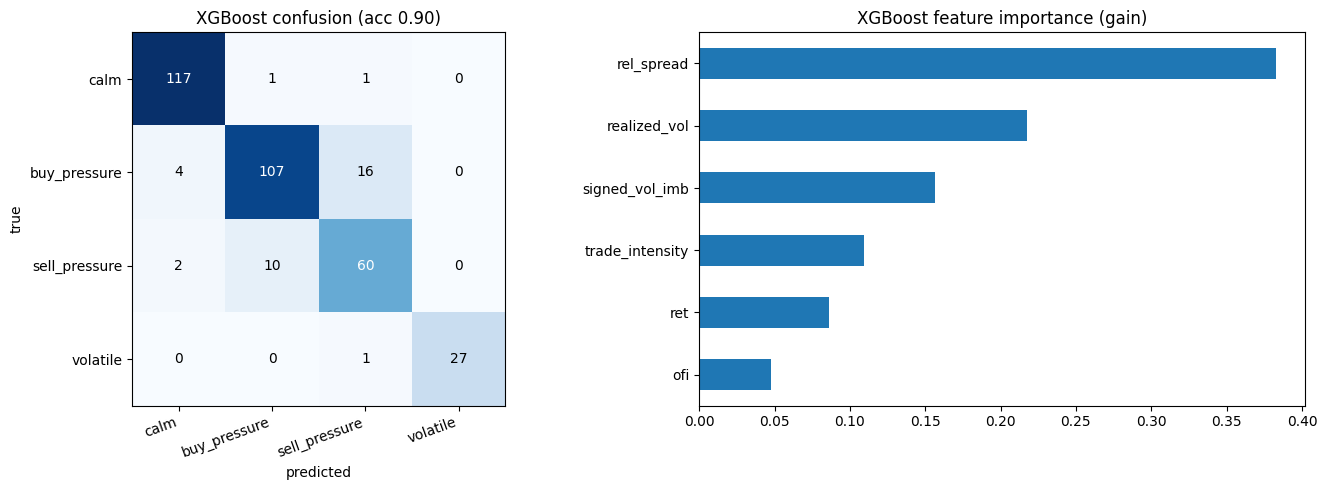

In [6]:
print("============== HMM vs XGBoost (test, out-of-sample) ==============")
print(f"{'model':22s}{'ARI':>8s}{'accuracy':>10s}{'macro-F1':>10s}")
print(f"{'GaussianHMM (unsup.)':22s}{hmm_ari:8.3f}{'n/a':>10s}{'n/a':>10s}")
print(f"{'XGBoost (supervised)':22s}{xgb_ari:8.3f}{xgb_acc:10.3f}{xgb_f1:10.3f}\n")

names = [REGIME_NAMES[i] for i in range(4)]
print(classification_report(regime_test, regime_pred, labels=[0, 1, 2, 3],
                            target_names=names, digits=3))

cm = confusion_matrix(regime_test, regime_pred, labels=[0, 1, 2, 3])
importance = pd.Series(xgb.feature_importances_, index=config.FEATURE_COLS).sort_values()

fig, (ax_cm, ax_imp) = plt.subplots(1, 2, figsize=(14, 5))
ax_cm.imshow(cm, cmap="Blues")
ax_cm.set_xticks(range(4)); ax_cm.set_xticklabels(names, rotation=20, ha="right")
ax_cm.set_yticks(range(4)); ax_cm.set_yticklabels(names)
ax_cm.set_xlabel("predicted"); ax_cm.set_ylabel("true")
ax_cm.set_title(f"XGBoost confusion (acc {xgb_acc:.2f})")
for i in range(4):
    for j in range(4):
        ax_cm.text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max() / 2 else "black")
importance.plot.barh(ax=ax_imp, color="#1f77b4")
ax_imp.set_title("XGBoost feature importance (gain)")
plt.tight_layout(); plt.show()

## What it means

- **Small gap (0.70 → 0.75 ARI).** XGBoost *with the answer key* barely beats the unsupervised HMM — so the HMM is a strong choice, and the limit is the **features**, not the model. The regimes overlap, and no model fully separates them.
- **Where the errors are.** The confusion matrix shows the hard axis is **direction** (buy ↔ sell pressure): those regimes have identical volatility/spread profiles and differ only in flow direction, so when the directional signal is noisy they blur. Volatile and calm are easy.
- **The diagnostic payoff.** Importance shows **`rel_spread` and `realized_vol`** carry the most regime signal, while **`ofi` is barely used** (likely redundant with `signed_vol_imb`) — which feeds straight back into improving the HMM's feature set.

## Honest caveats & what's next

**Caveats**
- **XGBoost needs labels that don't exist on the real feed.** Here they come from the synthetic generator; on real proprietary data, regimes are latent — there is no label column. This validates the *approach*, but supervised detection isn't free on real data.
- **Importances are partly a synthetic artifact** — the *direction* of findings should survive to real data; exact rankings will shift.

**Complementary, not strict rivals:** the **HMM** works unsupervised on the real feed day one; **XGBoost** is the supervised *ceiling + diagnostic*.

**What's next**
1. **Real data** — swap the synthetic feed for the company's order-flow API (the gating dependency).
2. **A regime forecaster** (built) — XGBoost forecasting the *next* bar's regime (~68% acc). Key finding: it forecasts *turbulence* well but **flickers**, because it classifies each bar independently with no persistence — exactly the temporal coherence the HMM's transition matrix provides.
3. **A hybrid** (next) — feed the HMM's regime posterior (`prob_0..prob_3`) as features to the XGBoost forecaster, marrying the HMM's persistence to XGBoost's microstructure signal. The hybrid can *beat* the HMM (not just imitate it), and it works on real data since the HMM's filtered state is causal.